# 04.3 - Supervised Learning: Komparasi Akurasi Klasifikasi

**Tujuan Analisis:**
Pada tahap *Unsupervised Learning* sebelumnya, Standard K-Means terbukti memenangkan seluruh evaluasi metrik (SSE terendah, Silhouette tertinggi). 

Di *notebook* ini, kita melakukan pengujian tahap kedua dari sudut pandang *Supervised Learning*. Pertanyaan utamanya adalah: **"Apakah kelompok (cluster) yang dihasilkan oleh algoritma tersebut memiliki pola yang cukup jelas untuk ditebak oleh AI?"**

Kita akan menguji keempat hasil *clustering* tersebut (Standard, DE, PSO, EOA) dengan dua model klasifikasi yang kita miliki:
1. **Decision Tree**
2. **Support Vector Machine (SVM)**

**Alur Kerja (Input & Output):**
* **Input:** 4 dataset hasil dari masing-masing metode *clustering*.
* **Proses:** Me-*looping* pelatihan data ke dalam DT dan SVM untuk mencatat akurasinya.
* **Output:** Visualisasi *Bar Chart* komparatif untuk melihat metode mana yang paling optimal secara keseluruhan.

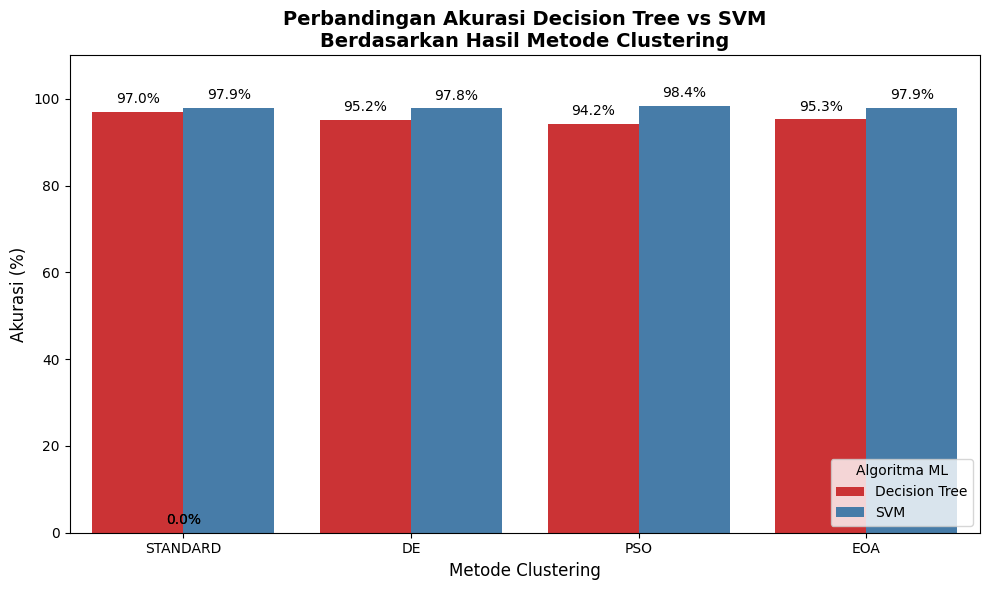

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# 1. Persiapkan daftar file CSV
file_datasets = [
    '../data/Labeled/hasildata_kmeans-standard.csv',
    '../data/Labeled/hasildata_kmeans-de.csv',
    '../data/Labeled/hasildata_kmeans-pso.csv',
    '../data/Labeled/hasildata_kmeans-eoa.csv'
]

data_hasil = []

# 2. Looping untuk menguji setiap dataset
for file in file_datasets:
    # Mengambil nama algoritma dari file (misal: 'STANDARD', 'DE')
    metode_clustering = file.split('-')[1].replace('.csv', '').upper()
    
    df = pd.read_csv(file)
    fitur = [f'Var{i}' for i in range(1, 12)]
    X = df[fitur]
    y = df['Cluster']
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # --- A. Prediksi menggunakan Decision Tree ---
    model_dt = DecisionTreeClassifier(random_state=42, max_depth=4)
    model_dt.fit(X_train, y_train)
    akurasi_dt = accuracy_score(y_test, model_dt.predict(X_test))
    
    data_hasil.append({
        'Metode Clustering': metode_clustering, 
        'Algoritma Klasifikasi': 'Decision Tree', 
        'Akurasi': akurasi_dt * 100
    })
    
    # --- B. Prediksi menggunakan SVM ---
    # Membatasi sampel data latih maksimal 2000 baris untuk mencegah processing delays
    X_train_svm = X_train[:2000]
    y_train_svm = y_train[:2000]
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_svm)
    X_test_scaled = scaler.transform(X_test)
    
    model_svm = SVC(kernel='rbf', random_state=42)
    model_svm.fit(X_train_scaled, y_train_svm)
    akurasi_svm = accuracy_score(y_test, model_svm.predict(X_test_scaled))
    
    data_hasil.append({
        'Metode Clustering': metode_clustering, 
        'Algoritma Klasifikasi': 'SVM', 
        'Akurasi': akurasi_svm * 100
    })

# 3. Ubah ke bentuk DataFrame untuk divisualisasikan
df_hasil = pd.DataFrame(data_hasil)

# 4. VISUALISASI HASIL KOMPARASI
plt.figure(figsize=(10, 6))

grafik = sns.barplot(
    data=df_hasil, 
    x='Metode Clustering', 
    y='Akurasi', 
    hue='Algoritma Klasifikasi',
    palette='Set1'
)

plt.title('Perbandingan Akurasi Decision Tree vs SVM\nBerdasarkan Hasil Metode Clustering', fontsize=14, fontweight='bold')
plt.xlabel('Metode Clustering', fontsize=12)
plt.ylabel('Akurasi (%)', fontsize=12)
plt.ylim(0, 110)
plt.legend(title='Algoritma ML', loc='lower right')

# Menampilkan angka persentase tepat di atas batang grafik
for p in grafik.patches:
    grafik.annotate(f"{p.get_height():.1f}%", 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha='center', va='center', 
                   xytext=(0, 9), 
                   textcoords='offset points',
                   fontsize=10)

plt.tight_layout()
plt.show()